In [1]:
import matplotlib.pyplot as plt
from math import comb
from collections import defaultdict

In [2]:
max_card_distribution = defaultdict(int)
min_card_distribution = defaultdict(int)
total_combinations = comb(52, 13)

for spades in range(14):
    for hearts in range(14):
        for diamonds in range(14):
            clubs = 13 - (spades + hearts + diamonds)
            if 0 <= clubs <= 13:
                max_value_of_cards = max(spades, hearts, diamonds, clubs)
                min_value_of_cards = min(spades, hearts, diamonds, clubs)
                combinations = (comb(13, spades) *
                                comb(13, hearts) *
                                comb(13, diamonds) *
                                comb(13, clubs))
                max_card_distribution[max_value_of_cards] += combinations
                min_card_distribution[min_value_of_cards] += combinations

In [3]:
sorted_max_card_distribution = dict(sorted(max_card_distribution.items(), key=lambda kvp: (-kvp[1], kvp[0])))
sorted_min_card_distribution = dict(sorted(min_card_distribution.items(), key=lambda kvp: (-kvp[1], kvp[0])))

print("-" * 104)

print(f"Maximum cards in bridge hand: ")
for (max_card, frequency) in sorted_max_card_distribution.items():
    probability = frequency / total_combinations

    print(f"Max cards: {max_card} | Probability: {probability * 100:.2f} % from total | "
          f"{frequency:_} frequency  | 1 from {1 / probability:_.1f} hands")

print("-" * 104)

--------------------------------------------------------------------------------------------------------
Maximum cards in bridge hand: 
Max cards: 5 | Probability: 44.34 % from total | 281_562_853_572 frequency  | 1 from 2.3 hands
Max cards: 4 | Probability: 35.08 % from total | 222_766_089_260 frequency  | 1 from 2.9 hands
Max cards: 6 | Probability: 16.55 % from total | 105_080_049_360 frequency  | 1 from 6.0 hands
Max cards: 7 | Probability: 3.53 % from total | 22_394_644_272 frequency  | 1 from 28.4 hands
Max cards: 8 | Probability: 0.47 % from total | 2_963_997_036 frequency  | 1 from 214.2 hands
Max cards: 9 | Probability: 0.04 % from total | 235_237_860 frequency  | 1 from 2_699.5 hands
Max cards: 10 | Probability: 0.00 % from total | 10_455_016 frequency  | 1 from 60_737.7 hands
Max cards: 11 | Probability: 0.00 % from total | 231_192 frequency  | 1 from 2_746_693.5 hands
Max cards: 12 | Probability: 0.00 % from total | 2_028 frequency  | 1 from 313_123_057.0 hands
Max cards: 1

In [4]:
print(f"Minimum cards in bridge hand: ")
for (min_card, frequency) in sorted_min_card_distribution.items():
    probability = frequency / total_combinations

    print(f"Min cards: {min_card} | Probability: {probability * 100:.2f} % from total | "
          f"{frequency:_} frequency | 1 from {1 / probability:_.1f} hands")

print("-" * 104)

Minimum cards in bridge hand: 
Min cards: 2 | Probability: 53.80 % from total | 341_657_192_448 frequency | 1 from 1.9 hands
Min cards: 1 | Probability: 30.55 % from total | 194_023_212_812 frequency | 1 from 3.3 hands
Min cards: 3 | Probability: 10.54 % from total | 66_905_856_160 frequency | 1 from 9.5 hands
Min cards: 0 | Probability: 5.11 % from total | 32_427_298_180 frequency | 1 from 19.6 hands
--------------------------------------------------------------------------------------------------------


----------------------------------------------------------------------------------------------------------------


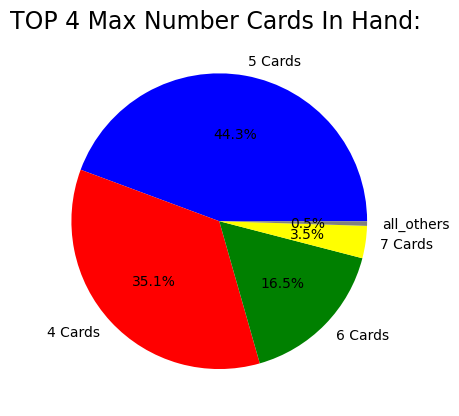

In [5]:
print("-" * 112)
top_4_max_card_items = dict(list(sorted_max_card_distribution.items())[:4])
top_4_max_card_value = sum(top_4_max_card_items.values())

top_4_max_card = {}
for (key, value) in top_4_max_card_items.items():
    top_4_max_card[f"{key} Cards"] = value

top_4_max_card["all_others"] = sum(max_card_distribution.values()) - top_4_max_card_value

top_4_keys = list(top_4_max_card.keys())
top_4_values = list(top_4_max_card.values())

colors = ["blue", "red", "green", "yellow", "grey"]
plt.pie(top_4_values, labels=top_4_keys, colors=colors, autopct="%1.1f%%")
plt.title("TOP 4 Max Number Cards In Hand: ", color="black", size=17)
plt.show()

----------------------------------------------------------------------------------------------------------------


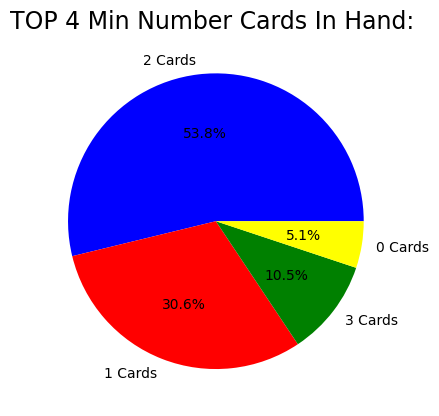

In [6]:
print("-" * 112)

if len(sorted_min_card_distribution) > 4:

    top_4_min_card_items = dict(list(sorted_min_card_distribution.items())[:4])
    top_4_min_card_value = sum(top_4_min_card_items.values())

    top_4_min_card = {}
    for (key, value) in top_4_min_card_items.items():
        top_4_min_card[f"{key} Cards"] = value

    top_4_min_card["all_others"] = sum(min_card_distribution.values()) - top_4_min_card_value
else:

    top_4_min_card = {}
    for (key, value) in sorted_min_card_distribution.items():
        top_4_min_card[f"{key} Cards"] = value

top_4_keys = list(top_4_min_card.keys())
top_4_values = list(top_4_min_card.values())

colors = ["blue", "red", "green", "yellow", "grey"]
plt.pie(top_4_values, labels=top_4_keys, colors=colors, autopct="%1.1f%%")
plt.title("TOP 4 Min Number Cards In Hand: ", color="black", size=17)
plt.show()
